!pip install -q

In [5]:

import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [6]:
import re
import time
import random
import math
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt



SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cuda


In [7]:
from google.colab import drive
drive.mount('/content/drive')

# EDIT this path to wherever your 6 CSVs live
DATA_DIR = '/content/drive/MyDrive/sanskrit-nmt/data/'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
def load_split(split):
    suffix = '_10000' if split == 'train' else '_1000'
    sa = pd.read_csv(f'{DATA_DIR}{split}_sa{suffix}.csv')
    en = pd.read_csv(f'{DATA_DIR}{split}_en{suffix}.csv')
    df = pd.merge(sa, en, on='Source_id')
    return df

train_df = load_split('train')
dev_df   = load_split('dev')
test_df  = load_split('test')

print('train:', train_df.shape, ' dev:', dev_df.shape, ' test:', test_df.shape)
train_df.head()

train: (10000, 3)  dev: (1000, 3)  test: (1000, 3)


,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


## Preprocessing & Vocabulary

In [9]:
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3
SPECIAL_TOKENS = ['<pad>', '<sos>', '<eos>', '<unk>']


def tokenize(text):
    text = str(text).strip()
    # separate common punctuation (including Devanagari danda '।') from words
    text = re.sub(r'([।,.!?;:"\'()])', r' \1 ', text)
    return text.split()

class Vocab:
    def __init__(self, sentences, min_freq=1):
        counter = Counter()
        for s in sentences:
            counter.update(tokenize(s))
        self.itos = list(SPECIAL_TOKENS)
        for word, freq in counter.items():
            if freq >= min_freq:
                self.itos.append(word)
        self.stoi = {w: i for i, w in enumerate(self.itos)}

    def encode(self, text, max_len=None):
        ids = [self.stoi.get(t, UNK_IDX) for t in tokenize(text)]
        ids = [SOS_IDX] + ids + [EOS_IDX]
        if max_len:
            ids = ids[:max_len]
        return ids

    def decode(self, ids):
        words = []
        for i in ids:
            if i == EOS_IDX:
                break
            if i in (PAD_IDX, SOS_IDX):
                continue
            words.append(self.itos[i])
        return ' '.join(words)

    def __len__(self):
        return len(self.itos)

SRC_VOCAB = Vocab(train_df['Sentence_sa'].tolist(), min_freq=1)
TGT_VOCAB = Vocab(train_df['Sentence_en'].tolist(), min_freq=1)
print('Sanskrit vocab size:', len(SRC_VOCAB))
print('English vocab size :', len(TGT_VOCAB))

Sanskrit vocab size: 29732
English vocab size : 12792


## Dataset & DataLoader

In [10]:
MAX_LEN = 64

class TranslationDataset(Dataset):
    def __init__(self, df, src_vocab, tgt_vocab, max_len=MAX_LEN):
        self.df = df.reset_index(drop=True)
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        src_ids = self.src_vocab.encode(row['Sentence_sa'], self.max_len)
        tgt_ids = self.tgt_vocab.encode(row['Sentence_en'], self.max_len)
        return torch.tensor(src_ids), torch.tensor(tgt_ids)

def collate_fn(batch):
    srcs, tgts = zip(*batch)
    src_lens = torch.tensor([len(s) for s in srcs])
    src_pad = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=PAD_IDX)
    tgt_pad = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=PAD_IDX)
    return src_pad, src_lens, tgt_pad

BATCH_SIZE = 32

train_ds = TranslationDataset(train_df, SRC_VOCAB, TGT_VOCAB)
dev_ds   = TranslationDataset(dev_df, SRC_VOCAB, TGT_VOCAB)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
dev_loader   = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print('train batches:', len(train_loader), ' dev batches:', len(dev_loader))

train batches: 313  dev batches: 32


## Model — Encoder
Bidirectional GRU encoder. Packs padded sequences for efficiency.

In [11]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(emb_dim, hid_dim, n_layers, bidirectional=True,
                           batch_first=True, dropout=dropout if n_layers > 1 else 0)
        self.fc = nn.Linear(hid_dim * 2, hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lens):
        embedded = self.dropout(self.embedding(src))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, src_lens.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, hidden = self.rnn(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2], hidden[-1]), dim=1)))
        return outputs, hidden  # outputs: (B, src_len, hid*2), hidden: (B, hid)

 ## Model — Bahdanau (Additive) Attention

In [12]:
class Attention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.attn = nn.Linear(hid_dim * 3, hid_dim)
        self.v = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs, mask):
        src_len = encoder_outputs.shape[1]
        hidden_rep = hidden.unsqueeze(1).repeat(1, src_len, 1)
        energy = torch.tanh(self.attn(torch.cat((hidden_rep, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)
        attention = attention.masked_fill(mask == 0, -1e10)
        return torch.softmax(attention, dim=1)  # (B, src_len)

## Model — Decoder (with attention)

In [13]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, attention, n_layers=1, dropout=0.3):
        super().__init__()
        self.attention = attention
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(hid_dim * 2 + emb_dim, hid_dim, n_layers,
                           batch_first=True, dropout=dropout if n_layers > 1 else 0)
        self.fc_out = nn.Linear(hid_dim * 3 + emb_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_tok, hidden, encoder_outputs, mask):
        input_tok = input_tok.unsqueeze(1)                     # (B,1)
        embedded = self.dropout(self.embedding(input_tok))     # (B,1,emb)
        a = self.attention(hidden, encoder_outputs, mask).unsqueeze(1)  # (B,1,src_len)
        weighted = torch.bmm(a, encoder_outputs)                # (B,1,hid*2)
        rnn_input = torch.cat((embedded, weighted), dim=2)
        output, hidden_new = self.rnn(rnn_input, hidden.unsqueeze(0))
        output, weighted, embedded = output.squeeze(1), weighted.squeeze(1), embedded.squeeze(1)
        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim=1))
        return prediction, hidden_new.squeeze(0)

## Seq2Seq Wrapper (teacher forcing)

In [14]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def create_mask(self, src):
        return (src != PAD_IDX)

    def forward(self, src, src_lens, tgt, teacher_forcing_ratio=0.5):
        batch_size, tgt_len = tgt.shape
        vocab_size = self.decoder.fc_out.out_features
        outputs = torch.zeros(batch_size, tgt_len, vocab_size).to(self.device)

        encoder_outputs, hidden = self.encoder(src, src_lens)
        mask = self.create_mask(src)
        input_tok = tgt[:, 0]  # <sos>

        for t in range(1, tgt_len):
            output, hidden = self.decoder(input_tok, hidden, encoder_outputs, mask)
            outputs[:, t] = output
            top1 = output.argmax(1)
            teacher_force = random.random() < teacher_forcing_ratio
            input_tok = tgt[:, t] if teacher_force else top1
        return outputs

## Instantiate Model & Optimizer

In [15]:
EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 1
DROPOUT = 0.3
LEARNING_RATE = 1e-3
CLIP = 1.0

attn = Attention(HID_DIM)
enc = Encoder(len(SRC_VOCAB), EMB_DIM, HID_DIM, N_LAYERS, DROPOUT)
dec = Decoder(len(TGT_VOCAB), EMB_DIM, HID_DIM, attn, N_LAYERS, DROPOUT)
model = Seq2Seq(enc, dec, DEVICE).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

Trainable parameters: 40,255,480


## Training & Evaluation Functions

In [16]:
def train_epoch(model, loader, optimizer, criterion, clip, tf_ratio):
    model.train()
    epoch_loss = 0
    for src, src_lens, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()
        output = model(src, src_lens, tgt, tf_ratio)
        output_dim = output.shape[-1]
        loss = criterion(output[:, 1:].reshape(-1, output_dim), tgt[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)

def evaluate_epoch(model, loader, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, src_lens, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            output = model(src, src_lens, tgt, teacher_forcing_ratio=0.0)
            output_dim = output.shape[-1]
            loss = criterion(output[:, 1:].reshape(-1, output_dim), tgt[:, 1:].reshape(-1))
            epoch_loss += loss.item()
    return epoch_loss / len(loader)

## Run Training

In [17]:
N_EPOCHS = 15
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(1, N_EPOCHS + 1):
    tf_ratio = max(0.3, 0.9 - 0.05 * epoch)  # decaying teacher forcing
    start = time.time()

    train_loss = train_epoch(model, train_loader, optimizer, criterion, CLIP, tf_ratio)
    val_loss = evaluate_epoch(model, dev_loader, criterion)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')

    mins = (time.time() - start) / 60
    print(f'Epoch {epoch:02d} | Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f} '
          f'| PPL: {math.exp(val_loss):7.2f} | Time: {mins:.1f}m')

model.load_state_dict(torch.load('best_model.pt'))
print('Loaded best checkpoint (lowest val loss).')

Epoch 01 | Train Loss: 5.639 | Val Loss: 6.415 | PPL:  611.12 | Time: 1.8m
Epoch 02 | Train Loss: 4.400 | Val Loss: 6.251 | PPL:  518.71 | Time: 1.8m
Epoch 03 | Train Loss: 3.500 | Val Loss: 6.367 | PPL:  582.28 | Time: 1.8m
Epoch 04 | Train Loss: 2.816 | Val Loss: 6.507 | PPL:  669.73 | Time: 1.8m
Epoch 05 | Train Loss: 2.502 | Val Loss: 6.645 | PPL:  768.65 | Time: 1.8m
Epoch 06 | Train Loss: 2.188 | Val Loss: 6.660 | PPL:  780.90 | Time: 1.8m
Epoch 07 | Train Loss: 1.950 | Val Loss: 6.671 | PPL:  789.13 | Time: 1.8m
Epoch 08 | Train Loss: 1.847 | Val Loss: 6.697 | PPL:  809.83 | Time: 1.8m
Epoch 09 | Train Loss: 1.731 | Val Loss: 6.716 | PPL:  825.27 | Time: 1.8m
Epoch 10 | Train Loss: 1.696 | Val Loss: 6.714 | PPL:  824.13 | Time: 1.8m
Epoch 11 | Train Loss: 1.673 | Val Loss: 6.710 | PPL:  820.84 | Time: 1.8m
Epoch 12 | Train Loss: 1.686 | Val Loss: 6.693 | PPL:  806.52 | Time: 1.8m
Epoch 13 | Train Loss: 1.616 | Val Loss: 6.708 | PPL:  818.69 | Time: 1.8m
Epoch 14 | Train Loss: 1.

## Training Curves (for report)

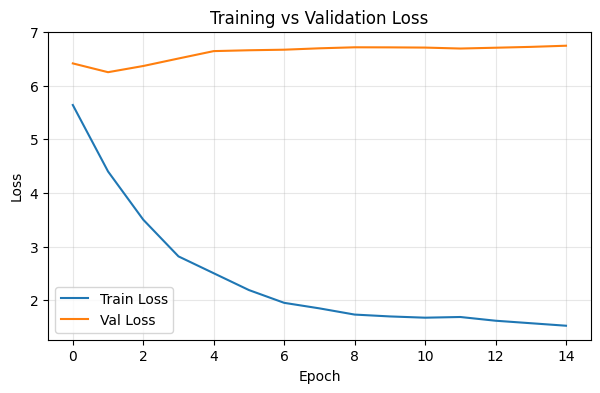

In [18]:
plt.figure(figsize=(7,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training vs Validation Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Beam Search Decoding
Used for generating final translations

In [19]:
def beam_search_decode(model, sentence, src_vocab, tgt_vocab, beam_width=3, max_len=MAX_LEN):
    model.eval()
    src_ids = torch.tensor(src_vocab.encode(sentence, max_len)).unsqueeze(0).to(DEVICE)
    src_len = torch.tensor([src_ids.shape[1]])

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_ids, src_len)
        mask = model.create_mask(src_ids)

        beams = [(0.0, [SOS_IDX], hidden)]
        completed = []

        for _ in range(max_len):
            new_beams = []
            for score, seq, hid in beams:
                if seq[-1] == EOS_IDX:
                    completed.append((score, seq))
                    continue
                input_tok = torch.tensor([seq[-1]]).to(DEVICE)
                output, hid_new = model.decoder(input_tok, hid, encoder_outputs, mask)
                log_probs = torch.log_softmax(output, dim=1).squeeze(0)
                topk_probs, topk_ids = log_probs.topk(beam_width)
                for i in range(beam_width):
                    new_beams.append((score + topk_probs[i].item(),
                                       seq + [topk_ids[i].item()], hid_new))
            if not new_beams:
                break
            new_beams.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
            beams = new_beams[:beam_width]

        completed.extend([(s, sq) for s, sq, _ in beams])
        completed.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
        return tgt_vocab.decode(completed[0][1])

# quick sanity check on a dev example
sample = dev_df.iloc[0]
print('Source :', sample['Sentence_sa'])
print('Reference:', sample['Sentence_en'])
print('Prediction:', beam_search_decode(model, sample['Sentence_sa'], SRC_VOCAB, TGT_VOCAB))

Source : ते वीराः ।
Reference: Those are brave men.
Prediction: They are tail-feathers .


## Generate Predictions for Test Set

In [20]:
predictions = []
start_time = time.time()

for _, row in test_df.iterrows():
    pred = beam_search_decode(model, row['Sentence_sa'], SRC_VOCAB, TGT_VOCAB, beam_width=3)
    predictions.append(pred)

inference_time = time.time() - start_time
print(f'Inference time for {len(test_df)} sentences: {inference_time:.2f}s')

submission = pd.DataFrame({
    'Source_id': test_df['Source_id'],
    'Sentence_en': predictions
})
submission.to_csv('submission.csv', index=False, encoding='utf-8')
submission.head()

Inference time for 1000 sentences: 169.68s


,Source_id,Sentence_en
0,1,We can see that the output has been successful...
1,2,""" But I say unto you , I will come , that ye m..."
2,3,"Next , we will click on the drop-down button ."
3,4,"Again , we have 1 to 1 1 , 1 1 1 1 . 1 1 . 1 1..."
4,5,""" And when I heard , and came to pass , and ca..."


 ## Evaluation — BLEU


In [21]:
from nltk.translate.bleu_score import corpus_bleu

references = [[tokenize(ref)] for ref in test_df['Sentence_en'].tolist()]
hypotheses = [tokenize(pred) for pred in predictions]

bleu_score = corpus_bleu(references, hypotheses)
print(f'BLEU score: {bleu_score:.4f}')

BLEU score: 0.0485


In [22]:
!pip install -q bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.2 MB/s eta 0:00:00


## Evaluation — BERTScore (F1, rescaled with baseline)

In [23]:
from bert_score import score as bert_score_fn

P, R, F1 = bert_score_fn(
    predictions,
    test_df['Sentence_en'].tolist(),
    lang='en',
    rescale_with_baseline=True
)
print(f'BERTScore F1 (mean): {F1.mean().item():.4f}')

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore F1 (mean): 0.1043


## Evaluation — Efficiency (Time & Parameters)

In [24]:
n_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {n_params:,}')
print(f'Total inference time on test set: {inference_time:.2f} seconds')
print(f'Avg time per sentence: {inference_time/len(test_df)*1000:.2f} ms')

Total parameters: 40,255,480
Total inference time on test set: 169.68 seconds
Avg time per sentence: 169.68 ms


## Translation Examples & Error Analysis (for report)

In [25]:
n_examples = 8
sample_idx = np.random.choice(len(test_df), size=n_examples, replace=False)

for i in sample_idx:
    src = test_df.iloc[i]['Sentence_sa']
    ref = test_df.iloc[i]['Sentence_en']
    pred = predictions[i]
    print(f'Source    : {src}')
    print(f'Reference : {ref}')
    print(f'Prediction: {pred}')
    print('-' * 60)

Source    : स्वराक्षराणाम् 'अच्' इति नाम ।
Reference : The name of the vowels is “ach”.
Prediction: We will get familiar .
------------------------------------------------------------
Source    : संस्कतज्ञानाभावे गीतायाः अवगमनं क्लेशाय एव ।
Reference : Lack of knowledge of Sanskrit is a problem for understanding of the Gita.
Prediction: We will also learn about to the .
------------------------------------------------------------
Source    : शनै: शनै: स्वपार्ष्णीम उत्थापयेत (यथा संभवम्) तथा स्वपादाङ्गुष्ठौ उत्तिष्ठेत । शरीरं यावत शक्यं कर्षयेत्
Reference : 3. Slowly raise the heels as much as you can and stand on toes. Stretch body up as much as possible.
Prediction: " To enhance , we have learnt about : " " " " " " " " " " " " " " " " " " " " " " " " " " " " " " " " " " " " " " " " . "
------------------------------------------------------------
Source    : FrontAccounting इण्टर्फ़ेस् उद्घट्यते ।
Reference : The FrontAccounting interface opens.
Prediction: FrontAccounting interface .


In [26]:
submission.to_csv('/content/drive/MyDrive/submission.csv', index=False)
print("Saved!")

Saved!
